# Número de especies clasificadas con categoría de conservación en el sistema nacional
Este indicador nacional cuantifica el número acumulado de taxa (especies, subespecies o variedades) de flora, fauna y funga nativa que han sido evaluados oficialmente y a los cuales se les ha asignado una categoría de riesgo bajo la normativa del Estado. Su objetivo es monitorear el progreso hacia la Meta Nacional I.4, la cual establece que para el año 2030 el país debe aumentar en al menos un 30% el número de especies clasificadas respecto a la línea base del año 2023. Incrementar este número es fundamental, ya que la clasificación oficial (Reglamento de Clasificación de Especies, RCE) es la herramienta jurídica habilitante para priorizar planes de recuperación, restringir la extracción y evaluar impactos ambientales.
El acceso a la planilla de datos del indicador se encuentra disponible aquí.

## Metodología de Cálculo 
El cálculo corresponde a la sumatoria simple del número total histórico de taxa que han finalizado exitosamente los distintos Procesos de Clasificación de Especies Silvestres liderados por el Estado. Para evaluar el avance hacia la meta, se establece como línea base el universo total de especies clasificadas acumuladas hasta el año 2023. La meta a 2030 requiere sumar una cantidad equivalente al 30% de esa línea base. El progreso anual se calcula como la proporción de nuevas especies incorporadas frente a la brecha total requerida.


# Capa 1: Observación y recolección
## Fuentes de Datos Utilizadas 
Los datos provienen directamente del Inventario Nacional de Especies y del registro oficial del Reglamento de Clasificación de Especies (RCE), administrado por el Ministerio del Medio Ambiente (MMA), cuyos resultados públicos y expedientes se encuentran disponibles en la plataforma institucional (https://clasificacionespecies.mma.gob.cl/).

In [40]:
import pandas as pd

# URL del archivo Excel en línea
url = (
    "https://clasificacionespecies.mma.gob.cl/wp-content/uploads/2025/06/"
    "NominaDeEspecies_SegunEstadoConservacion-Chile_actualizado_19noProcesoRCE_rev30junio2025.xlsx"
)

# Leer la hoja "Especies" directamente desde la URL
df = pd.read_excel(
    url,
    sheet_name="Especies"
)

# Verificación rápida
print(df.shape)
print(df.columns)

(1568, 43)
Index(['NOMBRE CIENTÍFICO', 'NOMBRE COMÚN', 'SINONIMIA incompleta',
       'HÁBITO \n(sólo plantas y fungi)', 'REINO', 'PHYLLUM /\nDIVISIÓN',
       'CLASE', 'ORDEN', 'FAMILIA',
       'ENDÉMICA\nrespecto de Chile\n \n-- = No presente en Chile\n\n? = dudoso',
       'DISTRIBUCIÓN REGIONES:\nANT= ANTARTICA\nDV= DESVENTURADAS\nIP= ISLA DE PASCUA\nJF= Arch. JUAN FERNÁNDEZ\nSG= SALAS Y GOMEZ\n? = Sin datos o de presencia dudosa o requiere confirmación',
       'Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo',
       'Valparaíso continental', 'Metropolitana', 'O'higgins', 'Maule',
       'Ñuble', 'Bío-Bío', 'Araucanía', 'De Los Ríos', 'De Los Lagos', 'Aysén',
       'Magallanes continental e insular', 'Antártica', 'Isla Pascua',
       'Salas y Gómez', 'Juan Fernandez', 'Desventuradas',
       'CATEGORÍA VIGENTE:\nCR = En peligro crítico\nDD = Datos insuficientes\nEN = En Peligro\nEW= Extinta en estado silvestre\nEX = Extinta\nLC = Preocupación menor\nNT = C

In [41]:
# ver valores de 'FUENTE DE CATEGORÍA VIGENTE:\nCAZA  = Reglamento Ley de CAZA\nRCE = Reglamento de Clasificación Especies.'
print(df['FUENTE DE CATEGORÍA VIGENTE:\nCAZA  = Reglamento Ley de CAZA\nRCE = Reglamento de Clasificación Especies.'].value_counts())

FUENTE DE CATEGORÍA VIGENTE:\nCAZA  = Reglamento Ley de CAZA\nRCE = Reglamento de Clasificación Especies.
RCE    1542
Name: count, dtype: int64


In [42]:
#filtrar df por 'FUENTE DE CATEGORÍA VIGENTE:\nCAZA  = Reglamento Ley de CAZA\nRCE = Reglamento de Clasificación Especies.' == 'RCE'
df = df[df['FUENTE DE CATEGORÍA VIGENTE:\nCAZA  = Reglamento Ley de CAZA\nRCE = Reglamento de Clasificación Especies.'] == 'RCE']
#imprimir dimensiones del df
print(df.shape)

(1542, 43)


In [43]:
# Crear columna de año de resolución desde la referencia/decreto vigente
df["anio_resolucion"] = (
    df["REFERENCIA o DECRETO\nCategoría Vigente"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .astype("Int64")  # permite NA
)

# Verificación rápida
df[[
    "REFERENCIA o DECRETO\nCategoría Vigente",
    "anio_resolucion"
]].head(10)


,REFERENCIA o DECRETO\nCategoría Vigente,anio_resolucion
0,DS 16/2016 MMA,2016
1,DS 23/2019 MMA,2019
2,DS 19/2012 MMA,2012
3,DS 33/2011 MMA,2011
4,DS 06/2017 MMA,2017
5,DS 06/2017 MMA,2017
6,DS 44/2021 MMA,2021
7,DS 44/2021 MMA,2021
8,DS 44/2021 MMA,2021
9,DS 06/2017 MMA,2017


In [44]:
import re
import numpy as np

col_fuente_anteprev = "Fuente Categoría  ANTE ANTERIOR a RCE actual  \n(NO VIGENTE)\n(Ver valores en columna adyacente)"

def extraer_anio_previo(texto):
    if pd.isna(texto):
        return np.nan
    
    t = str(texto)
    
    # 1️⃣ Buscar patrón RCE con decreto (ej: DS 51/2008)
    match = re.search(r"DS\s*\d+\/(\d{4})", t)
    if match:
        return int(match.group(1))
    
    # 2️⃣ Asignar año según fuente histórica
    t_upper = t.upper()
    
    if "BOL_47" in t_upper:
        return 1998
    
    if "CAZA" in t_upper:
        return 1998
    
    if "L_ROJO_FLORA" in t_upper:
        return 1989
    
    if "L_ROJO_VERT" in t_upper:
        return 1988
    
    if "NÚÑEZ ET AL. 1997" in t_upper or "NUNEZ ET AL. 1997" in t_upper:
        return 1997
    
    if "YÁÑEZ ET AL. 1997" in t_upper or "YANEZ ET AL. 1997" in t_upper:
        return 1997
    
    return np.nan

df["anio_clasificacion_previa"] = df[col_fuente_anteprev].apply(extraer_anio_previo)

# Verificación rápida
df[[
    col_fuente_anteprev,
    "anio_clasificacion_previa"
]].head(20)

,Fuente Categoría ANTE ANTERIOR a RCE actual \n(NO VIGENTE)\n(Ver valores en columna adyacente),anio_clasificacion_previa
0,NaN,NaN
1,CAZA\nL_ROJO_Vert,1998.0
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


# Capa 2: Análisis y síntesis
### Número de especies nuevas por año

In [45]:
# Conteo de número de especies por año de resolución
conteo_por_anio = (
    df
    .dropna(subset=["anio_resolucion", "NOMBRE CIENTÍFICO"])
    .groupby("anio_resolucion")["NOMBRE CIENTÍFICO"]
    .nunique()
    .reset_index(name="n_especies")
    .sort_values("anio_resolucion")
)

# Ver resultado
print(conteo_por_anio)


    anio_resolucion  n_especies
0              1998           2
1              2007          18
2              2008          89
3              2009          87
4              2011         286
5              2012          89
6              2013         105
7              2014         103
8              2015          97
9              2016          83
10             2017         117
11             2018          52
12             2019          87
13             2020         100
14             2021         100
15             2023          68
16             2024          59


In [46]:
# Columnas relevantes
col_prev = "Categoría ANTERIOR a RCE actual\n(NO VIGENTE)\nBol_47 = Boletín 47 MNHN\nCAZA  = Reglamento Ley de CAZA\nL_Rojo_Flora = Libro Rojo de flora\nL_Rojo_Vert = Libro Rojo de vertebrados\nNúñez et al. 1997 = Reunión de herpetólogos\nYáñez et al. 1997 = Reunión especialistas mamíferos acuáticos\nRCE = Reglamento de Clasificación Especies."

col_anteprev = "Categoría ANTE ANTERIOR a RCE actual \n(NO VIGENTE)\nBol_47 = Boletín 47 MNHN\nCAZA  = Reglamento Ley de CAZA\nL_Rojo_Flora = Libro Rojo de flora\nL_Rojo_Vert = Libro Rojo de vertebrados\nNúñez et al. 1997 = Reunión de herpetólogos\nYáñez et al. 1997 = Reunión especialistas mamíferos acuáticos\nRCE = Reglamento de Clasificación Especies."

def vacio(x):
    if pd.isna(x):
        return True
    s = str(x).strip().upper()
    return s in ["", "NAN", "NA", "N/A", "--"]

# Es nueva si NO tiene clasificación previa
df["es_nueva"] = (
    df[col_prev].apply(vacio) &
    df[col_anteprev].apply(vacio)
)

In [47]:
def tiene_clasificacion_previa(x):
    if pd.isna(x):
        return False
    s = str(x).strip().upper()
    return s not in ["", "NAN", "NA", "N/A", "--"]

df["tiene_previa"] = (
    df[col_prev].apply(tiene_clasificacion_previa) |
    df[col_anteprev].apply(tiene_clasificacion_previa)
)

In [48]:
df_2024 = df[df["anio_resolucion"] == 2024]

nuevas_2024 = df_2024[~df_2024["tiene_previa"]]
reclas_2024 = df_2024[df_2024["tiene_previa"]]

print("Nuevas 2024:", nuevas_2024["NOMBRE CIENTÍFICO"].nunique())
print("Reclasificaciones 2024:", reclas_2024["NOMBRE CIENTÍFICO"].nunique())

Nuevas 2024: 38
Reclasificaciones 2024: 21


especies_historicas = set(
    df.loc[
        (df["anio_resolucion"] <= 2023) |
        ((df["anio_resolucion"] == 2024) & (df["tiene_previa"])),
        "NOMBRE CIENTÍFICO"
    ]
)

len(especies_historicas)

# Capa 3: 

## Resultados
De acuerdo con el instrumento oficial, la evaluación del progreso arroja los siguientes resultados concretos:
Línea Base (2023): El país registró un total acumulado de 1.504 especies con clasificación de categoría de conservación.
Meta (2030): Para lograr el incremento del 30% exigido por la Meta Nacional I.4, Chile requiere incorporar aproximadamente 451 especies adicionales al sistema antes de que finalice la década.
Avance Actual (2024): Como resultado del 19° Proceso de Clasificación de Especies Silvestres, se logró un incremento de 38 taxa, alcanzando un total de 1.542 especies clasificadas.
Nivel de Cumplimiento: La incorporación de estas 38 especies equivale a un aumento aproximado del 2,5% respecto a la línea base, lo que se traduce en el cumplimiento de un 8% del objetivo propuesto (38 de las 451 especies requeridas).


### Número de especies con categoría de conservación

In [49]:
universo_total = set(df["NOMBRE CIENTÍFICO"])
len(universo_total)

1542

In [50]:
tabla_anio_reino = (
    df
    .dropna(subset=["anio_resolucion", "NOMBRE CIENTÍFICO", "REINO"])
    .groupby(["anio_resolucion", "REINO"])["NOMBRE CIENTÍFICO"]
    .nunique()
    .reset_index(name="n_especies")
    .sort_values(["anio_resolucion", "REINO"])
)

print(tabla_anio_reino)


    anio_resolucion     REINO  n_especies
0              1998  Animalia           2
1              2007  Animalia           9
2              2007   Plantae           9
3              2008  Animalia          44
4              2008   Plantae          45
5              2009  Animalia          18
6              2009   Plantae          69
7              2011  Animalia          96
8              2011   Plantae         190
9              2012  Animalia          20
10             2012   Plantae          69
11             2013  Animalia           9
12             2013   Plantae          96
13             2014  Animalia          58
14             2014   Plantae          45
15             2015  Animalia          60
16             2015     Fungi          22
17             2015   Plantae          15
18             2016  Animalia          68
19             2016   Plantae          15
20             2017  Animalia          96
21             2017     Fungi           6
22             2017   Plantae     

In [51]:
tabla_anio_reino_wide = (
    tabla_anio_reino
    .pivot(index="anio_resolucion", columns="REINO", values="n_especies")
    .fillna(0)
    .astype(int)
)

print(tabla_anio_reino_wide)

REINO            Animalia  Fungi  Plantae
anio_resolucion                          
1998                    2      0        0
2007                    9      0        9
2008                   44      0       45
2009                   18      0       69
2011                   96      0      190
2012                   20      0       69
2013                    9      0       96
2014                   58      0       45
2015                   60     22       15
2016                   68      0       15
2017                   96      6       15
2018                   27     16        9
2019                   66     16        5
2020                   45     45       10
2021                   60     21       19
2023                   37      6       25
2024                   15      5       39


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Conteo anual por año y reino
anio_reino = (
    df
    .dropna(subset=["anio_resolucion", "NOMBRE CIENTÍFICO", "REINO"])
    .groupby(["anio_resolucion", "REINO"])["NOMBRE CIENTÍFICO"]
    .nunique()
    .reset_index(name="n_especies")
    .sort_values("anio_resolucion")
)

# Acumulado por reino
anio_reino["n_especies_acumuladas"] = (
    anio_reino
    .groupby("REINO")["n_especies"]
    .cumsum()
)


#vamos a crear una tabla del acumulado por año y reino
tabla_acumulado_reino = (
    anio_reino
    .pivot(index="anio_resolucion", columns="REINO", values="n_especies_acumuladas")
    .fillna(0)
    .astype(int)
)
print(tabla_acumulado_reino)

REINO            Animalia  Fungi  Plantae
anio_resolucion                          
1998                    2      0        0
2007                   11      0        9
2008                   55      0       54
2009                   73      0      123
2011                  169      0      313
2012                  189      0      382
2013                  198      0      478
2014                  256      0      523
2015                  316     22      538
2016                  384      0      553
2017                  480     28      568
2018                  507     44      577
2019                  573     60      582
2020                  618    105      592
2021                  678    126      611
2023                  715    132      636
2024                  730    137      675


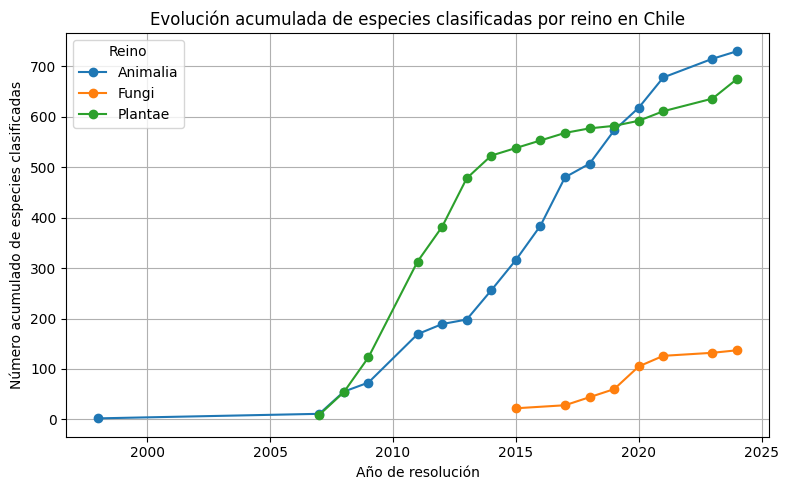

In [53]:
plt.figure(figsize=(8, 5))

for reino, df_reino in anio_reino.groupby("REINO"):
    plt.plot(
        df_reino["anio_resolucion"],
        df_reino["n_especies_acumuladas"],
        marker="o",
        label=reino
    )

plt.xlabel("Año de resolución")
plt.ylabel("Número acumulado de especies clasificadas")
plt.title("Evolución acumulada de especies clasificadas por reino en Chile")
plt.legend(title="Reino")
plt.grid(True)

plt.tight_layout()
plt.savefig("especies_clasificadas_por_reino.png", dpi=300, bbox_inches="tight")
plt.show()


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar solo Plantae y Animalia
df_pa = (
    df
    .query("REINO in ['Plantae', 'Animalia']")
    .dropna(subset=["anio_resolucion", "NOMBRE CIENTÍFICO", "REINO", "CLASE"])
)

# Conteo anual por reino y clase
anio_reino_clase = (
    df_pa
    .groupby(["anio_resolucion", "REINO", "CLASE"])["NOMBRE CIENTÍFICO"]
    .nunique()
    .reset_index(name="n_especies")
    .sort_values("anio_resolucion")
)

# Acumulado por reino y clase
anio_reino_clase["n_especies_acumuladas"] = (
    anio_reino_clase
    .groupby(["REINO", "CLASE"])["n_especies"]
    .cumsum()
)

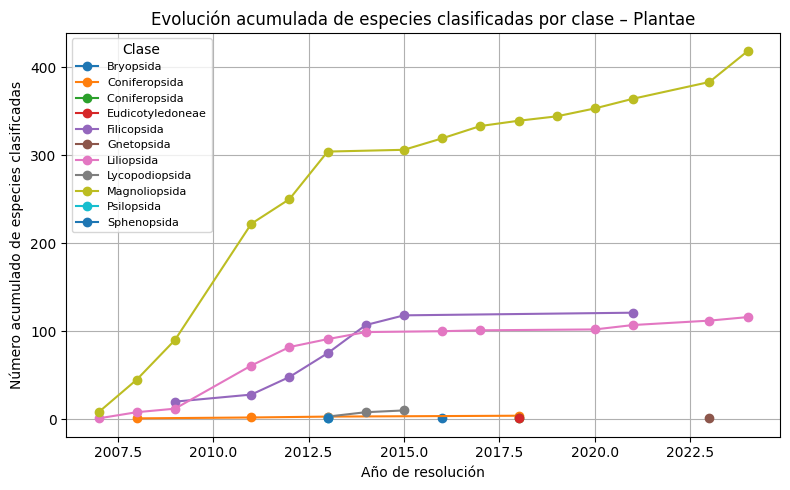

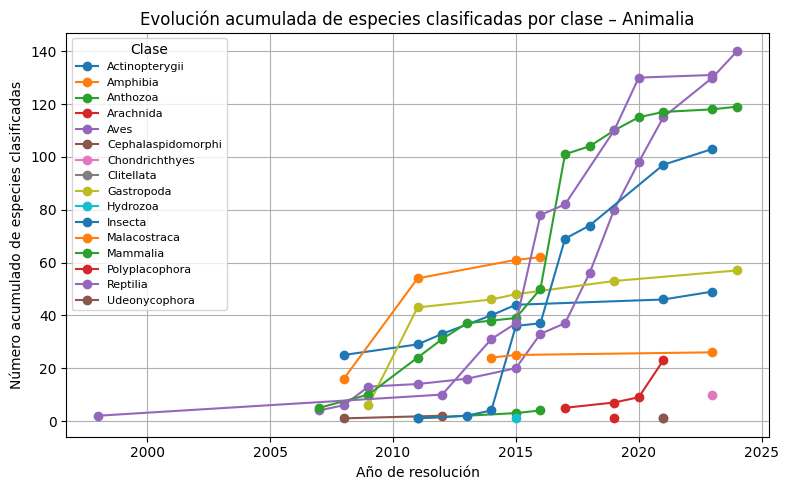

In [55]:
for reino in ["Plantae", "Animalia"]:
    plt.figure(figsize=(8, 5))

    df_reino = anio_reino_clase[anio_reino_clase["REINO"] == reino]

    for clase, df_clase in df_reino.groupby("CLASE"):
        plt.plot(
            df_clase["anio_resolucion"],
            df_clase["n_especies_acumuladas"],
            marker="o",
            label=clase
        )

    plt.xlabel("Año de resolución")
    plt.ylabel("Número acumulado de especies clasificadas")
    plt.title(f"Evolución acumulada de especies clasificadas por clase – {reino}")
    plt.legend(title="Clase", fontsize=8)
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"especies_clasificadas_por_clase_{reino}.png", dpi=300, bbox_inches="tight")
    plt.show()


## Observaciones

El seguimiento de este indicador demuestra contar con una línea base robusta y un mecanismo de actualización formal y continuo (los procesos anuales del RCE). La métrica refleja el resultado administrativo del esfuerzo estatal, cumpliendo su función de medir el progreso cuantitativo de ingresos al sistema. Sin embargo, como se detalla a continuación, el valor numérico global por sí solo no permite visibilizar la representatividad ecológica de lo que se está midiendo.

## Brechas

El análisis técnico de este indicador y sus fuentes de información revela importantes desafíos estructurales que deben subsanarse para agilizar el cumplimiento de la meta:
El análisis técnico de este indicador y de la base de datos que lo sustenta revela limitaciones metodológicas que condicionan la interpretación de la cifra final:
- Sesgo de representatividad en el valor numérico: El indicador contabiliza el total de "taxa", sin embargo, al analizar la evolución de la métrica por reinos, se evidencia que grupos como los invertebrados y el reino Fungi están subrepresentados. En consecuencia, el aumento numérico del indicador refleja en gran medida la disponibilidad histórica de datos sesgada hacia vertebrados y plantas.
- Limitaciones de trazabilidad en la base de datos: La herramienta subyacente a este indicador (la planilla de registro del MMA) presenta una arquitectura de datos plana. Esto dificulta realizar un seguimiento relacional a los cambios de estado de una misma especie a lo largo de los años (p. ej., cuando una especie es reevaluada y cambia de categoría). Por lo tanto, el indicador es útil para arrojar un "conteo total acumulado", pero pierde eficacia técnica cuando se intenta extraer de él tendencias de mejora o deterioro temporal de las especies.
- Incertidumbre por falta de estandarización taxonómica: La taxonomía es una disciplina dinámica donde las especies pueden cambiar de nomenclatura o se agrupan según nuevos estudios filogenéticos. Actualmente, el registro del RCE carece de un mecanismo automatizado de sincronización con las actualizaciones del Catálogo Nacional de Especies.


In [56]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# -----------------------------
# Preparación de datos
# -----------------------------
base = df.copy()

columnas_taxonomicas = [col for col in ["REINO", "FILO", "CLASE", "ORDEN", "FAMILIA"] if col in base.columns]

candidatas_especie = ["NOMBRE CIENTÍFICO", "scientificName", "especie", "species"]
col_especie = next((c for c in candidatas_especie if c in base.columns), None)
if col_especie is None:
    raise ValueError("No se encontró una columna de especie reconocible en el dataframe.")

base["anio_resolucion"] = pd.to_numeric(base["anio_resolucion"], errors="coerce")
base = base.dropna(subset=["anio_resolucion", col_especie]).copy()
base["anio_resolucion"] = base["anio_resolucion"].astype(int)

for col in columnas_taxonomicas:
    base[col] = (
        base[col]
        .fillna("Sin dato")
        .astype(str)
        .str.strip()
        .replace("", "Sin dato")
    )

cols_dedup = ["anio_resolucion", col_especie] + columnas_taxonomicas
base = base.drop_duplicates(subset=cols_dedup)

# -----------------------------
# Reinos
# -----------------------------
reinos = sorted(base["REINO"].dropna().unique().tolist()) if "REINO" in base.columns else []
lista_reinos = ["Todos"] + reinos

# -----------------------------
# Funciones auxiliares
# -----------------------------
def construir_serie(datos):
    if datos.empty:
        return pd.DataFrame(columns=["anio_resolucion", "n_especies", "n_especies_acumuladas"])

    serie = (
        datos.groupby("anio_resolucion")[col_especie]
        .nunique()
        .reset_index(name="n_especies")
        .sort_values("anio_resolucion")
    )
    serie["n_especies_acumuladas"] = serie["n_especies"].cumsum()
    return serie


def construir_treemap_tabla(datos, profundidad="CLASE"):
    columnas_disponibles = [c for c in ["REINO", "FILO", "CLASE", "ORDEN", "FAMILIA"] if c in datos.columns]

    if profundidad not in columnas_disponibles:
        profundidad = columnas_disponibles[-1]

    path = columnas_disponibles[:columnas_disponibles.index(profundidad) + 1]

    tabla = (
        datos.groupby(path)[col_especie]
        .nunique()
        .reset_index(name="n_especies")
    )
    return tabla, path


# -----------------------------
# Precalcular datos por reino
# -----------------------------
series_por_reino = {}
treemap_por_reino = {}

profundidad_treemap = "CLASE" if "CLASE" in columnas_taxonomicas else columnas_taxonomicas[-1]

for reino in lista_reinos:
    datos = base if reino == "Todos" else base[base["REINO"] == reino].copy()
    series_por_reino[reino] = construir_serie(datos)
    treemap_por_reino[reino] = construir_treemap_tabla(datos, profundidad=profundidad_treemap)

# -----------------------------
# Figura 1: línea
# -----------------------------
fig_linea = go.Figure()

for reino in lista_reinos:
    serie = series_por_reino[reino]

    fig_linea.add_trace(
        go.Scatter(
            x=serie["anio_resolucion"],
            y=serie["n_especies"],
            mode="lines+markers",
            name=f"{reino} - anual",
            visible=False,
            hovertemplate="Año: %{x}<br>Especies nuevas: %{y}<extra></extra>"
        )
    )

    fig_linea.add_trace(
        go.Scatter(
            x=serie["anio_resolucion"],
            y=serie["n_especies_acumuladas"],
            mode="lines+markers",
            name=f"{reino} - acumulada",
            visible=False,
            hovertemplate="Año: %{x}<br>Especies acumuladas: %{y}<extra></extra>"
        )
    )

# Visible por defecto: Todos acumulada
if len(fig_linea.data) > 1:
    fig_linea.data[1].visible = True

botones_linea = []
for i, reino in enumerate(lista_reinos):
    visibles = [False] * len(fig_linea.data)
    visibles[2 * i + 1] = True  # acumulada por defecto

    serie = series_por_reino[reino]
    total = int(serie["n_especies"].sum()) if not serie.empty else 0
    primer_anio = int(serie["anio_resolucion"].min()) if not serie.empty else "-"
    ultimo_anio = int(serie["anio_resolucion"].max()) if not serie.empty else "-"

    botones_linea.append(
        dict(
            label=reino,
            method="update",
            args=[
                {"visible": visibles},
                {
                    "title": f"Número acumulado de especies clasificadas — {reino}",
                    "annotations": [
                        dict(
                            x=0, y=1.12, xref="paper", yref="paper",
                            text=f"Total de especies únicas: {total} | Rango temporal: {primer_anio}–{ultimo_anio}",
                            showarrow=False, xanchor="left", align="left"
                        )
                    ]
                }
            ]
        )
    )

fig_linea.update_layout(
    title="Número acumulado de especies clasificadas — Todos",
    template="plotly_white",
    hovermode="x unified",
    autosize=True,
    height=360,
    margin=dict(l=40, r=20, t=90, b=40),
    xaxis=dict(title="Año de resolución", dtick=1),
    yaxis=dict(title="Especies acumuladas"),
    annotations=[
        dict(
            x=0, y=1.12, xref="paper", yref="paper",
            text=(
                f"Total de especies únicas: "
                f"{int(series_por_reino['Todos']['n_especies'].sum()) if not series_por_reino['Todos'].empty else 0}"
            ),
            showarrow=False,
            xanchor="left",
            align="left"
        )
    ],
    updatemenus=[
    dict(
        type="buttons",
        direction="right",
        x=0.78,          # pegado a la izquierda
        y=1.3,          # bajo el título
        xanchor="left",
        yanchor="top",
        pad={"r":8,"t":0},
            showactive=True,
            buttons=botones_linea
        )
    ]
)

# -----------------------------
# Figura 2: treemap
# -----------------------------
fig_tree = go.Figure()

for i, reino in enumerate(lista_reinos):
    tabla_tree, path_tree = treemap_por_reino[reino]

    if tabla_tree.empty:
        fig_tree.add_trace(
            go.Treemap(
                labels=["Sin datos"],
                parents=[""],
                values=[1],
                visible=(i == 0),
                textinfo="label"
            )
        )
    else:
        fig_tmp = px.treemap(
            tabla_tree,
            path=path_tree,
            values="n_especies"
        )

        trace = fig_tmp.data[0]
        trace.visible = (i == 0)
        fig_tree.add_trace(trace)

botones_tree = []
for i, reino in enumerate(lista_reinos):
    visibles = [False] * len(fig_tree.data)
    visibles[i] = True

    botones_tree.append(
        dict(
            label=reino,
            method="update",
            args=[
                {"visible": visibles},
                {"title": f"Composición taxonómica por número de especies únicas — {reino}"}
            ]
        )
    )

fig_tree.update_layout(
    title="Composición taxonómica por número de especies únicas — Todos",
    template="plotly_white",
    autosize=True,
    height=520,
    margin=dict(l=20, r=20, t=90, b=20),
   updatemenus=[
    dict(
        type="buttons",
        direction="right",
        x=0.78,          # pegado a la izquierda
        y=1.08,          # bajo el título
        xanchor="left",
        yanchor="top",
        pad={"r":8,"t":0},
            showactive=True,
            buttons=botones_tree
        )
    ]
)

# -----------------------------
# Mostrar
# -----------------------------
fig_linea.show(config={"responsive": True})
fig_tree.show(config={"responsive": True})